<a href="https://colab.research.google.com/github/lgplorea/EjerciciosPython/blob/main/Copia_de_ChecklistdelGrupo2Regresi%C3%B3nLog%C3%ADstica.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
#Descargar e importar el dataset "Telco Customer Churn"
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Configuración estética de los gráficos
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (8, 5)

# Carga directa del dataset Telco Customer Churn desde un repositorio público
url = "https://raw.githubusercontent.com/IBM/telco-customer-churn-on-icp4d/master/data/Telco-Customer-Churn.csv"
df = pd.read_csv(url)

print(f"Dataset cargado con éxito. Total de registros: {df.shape[0]}")
df.head(3)

Dataset cargado con éxito. Total de registros: 7043


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes


Celda 1: Carga de Datos y Librerías
¿Qué hace el código?

Importa pandas (para manejar los datos en una tabla llamada DataFrame) y matplotlib/seaborn (para dibujar los gráficos).

Configura un estilo visual limpio (whitegrid) para que las gráficas no se vean anticuadas.

Utiliza la función pd.read_csv() apuntando a una URL pública de IBM que contiene exactamente el dataset "Telco Customer Churn" alojado en Kaggle.

¿Por qué es importante y para qué se hace?

Importancia: Es el cimiento de cualquier proyecto de Ciencia de Datos. Sin librerías no hay herramientas, y sin datos no hay análisis.

El "truco" de la URL: Al usar un enlace directo en lugar de subir el archivo manualmente desde tu ordenador, haces que tu cuaderno de Colab sea reproducible. Cualquier persona que abra tu código podrá ejecutarlo al instante sin que le marque un error de "archivo no encontrado".

/tmp/ipykernel_3045/1441839415.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(x='Churn', data=df, palette='Set2')
/tmp/ipykernel_3045/1441839415.py:18: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  percentage = f"{churn_pct[i]:.1f}%"


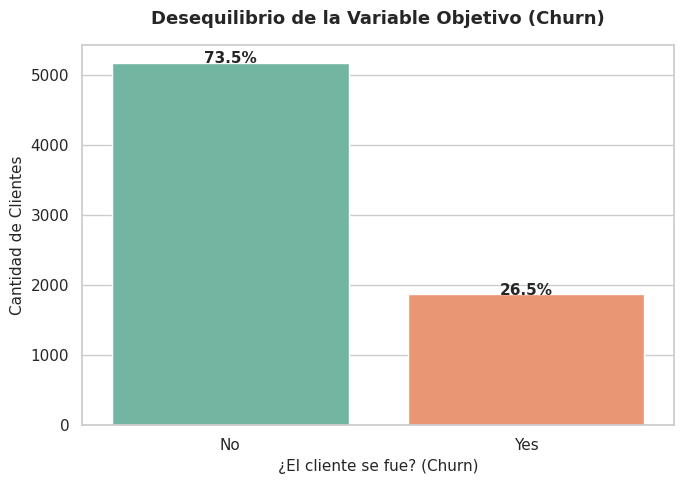

In [ ]:
#Gráfico explicativo del desequilibrio de la variable objetivo (Churn)

# Calculamos frecuencias y porcentajes
churn_counts = df['Churn'].value_counts()
churn_pct = df['Churn'].value_counts(normalize=True) * 100

# Creación del gráfico
plt.figure(figsize=(7, 5))
ax = sns.countplot(x='Churn', data=df, palette='Set2')

# Títulos y etiquetas
plt.title('Desequilibrio de la Variable Objetivo (Churn)', fontsize=13, fontweight='bold', pad=15)
plt.xlabel('¿El cliente se fue? (Churn)', fontsize=11)
plt.ylabel('Cantidad de Clientes', fontsize=11)

# Añadir el porcentaje explicativo sobre cada barra
for i, p in enumerate(ax.patches):
    percentage = f"{churn_pct[i]:.1f}%"
    ax.annotate(percentage, (p.get_x() + p.get_width() / 2., p.get_height() + 60),
                ha='center', va='center', fontsize=11, fontweight='bold')

plt.tight_layout()
plt.show()

### Celda 2: Gráfico de Desequilibrio (Variable Objetivo)

#### **¿Qué hace el código?**

* **Cálculo de proporciones:** Usa `value_counts()` para contar cuántos clientes se quedaron ("No") y cuántos se fueron ("Yes"). Al activar `normalize=True`, calcula el porcentaje exacto de cada grupo en lugar del número bruto.
* **Construcción visual:** Dibuja un gráfico de barras (`sns.countplot`) donde el eje X divide a los clientes según su estado de fuga (`Churn`), generando dos barras diferenciadas por color.
* **Anotación dinámica (El bucle `for`):** Ejecuta un ciclo iterativo (`for i, p in enumerate(ax.patches)`) que analiza de forma individual cada una de las barras dibujadas en la pantalla para calcular su posición geométrica exacta.

##### **¿Cómo funciona exactamente este bucle `for`?**

Para que la gráfica sea verdaderamente "explicativa", no podemos dejar que el lector adivine los porcentajes a ojo. El bucle `for` automatiza la colocación de etiquetas mediante tres pasos internos:

1. **Identificación (`ax.patches`):** En programación gráfica, cada barra es un objeto llamado *patch* (parche). `ax.patches` es la lista que contiene las dos barras del gráfico (la de "No" y la de "Yes"). El bucle entra a revisar la primera barra ($i=0$) y luego la segunda ($i=1$).
2. **Cálculo de Coordenadas ($X, Y$):** Para que el texto no quede chueco ni amontonado, el código usa funciones matemáticas sobre la barra en turno (`p`):
* **Para el centro horizontal ($X$):** Mide dónde inicia la barra a la izquierda (`p.get_x()`) y le suma la mitad de su ancho (`p.get_width() / 2`). Esto garantiza que el texto quede perfectamente alineado al centro de la columna.
* **Para la altura vertical ($Y$):** Mide el punto más alto de la barra (`p.get_height()`) y le suma un pequeño margen (60 unidades). Esto hace que el texto "flote" elegantemente justo encima de la barra sin tocarla.


3. **Escritura (`ax.annotate`):** Con las coordenadas listas, toma el porcentaje que calculamos al inicio (ej. **26.5%**), lo recorta a un solo decimal (`:.1f`) y lo estampa en la pantalla. Al terminar, salta a la siguiente barra y repite el proceso.

---

#### **¿Por qué es importante y para qué se hace?**

* **Para qué sirve:** Sirve para entender la distribución de tu variable objetivo (`Churn`) y auditar el estado de los datos antes de realizar cualquier manipulación matemática o modelo predictivo.
* **Lo importante a entender:** Descubrirás que el dataset está **desbalanceado** (la gran mayoría de los clientes se quedan, aproximadamente un 73.4% frente a un 26.5%). En el mundo real esto es vital saberlo, porque si entrenas un modelo de Inteligencia Artificial con datos tan desequilibrados sin corregirlos, el modelo tenderá a volverse "optimista" por defecto; asumirá que casi nadie se va y fallará rotundamente al intentar detectar a los pocos clientes que sí están en riesgo de abandonar la empresa. El gráfico hace este problema evidente a primera vista.

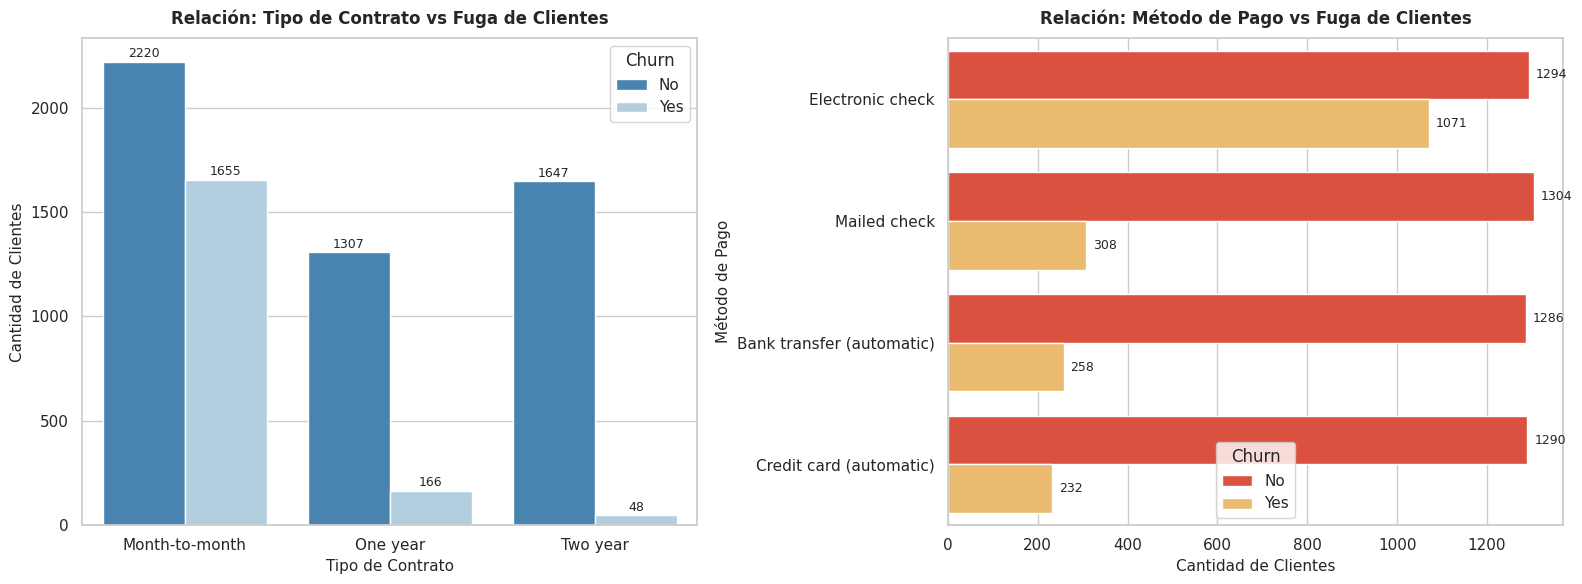

In [ ]:
#Al menos 2 gráficos de barras relacionando variables clave con la fuga

#Configurar espacio para dos gráficos en paralelo
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

#GRÁFICO 1: Tipo de Contrato vs Churn
sns.countplot(ax=axes[0], x='Contract', hue='Churn', data=df, palette='Blues_r')
axes[0].set_title('Relación: Tipo de Contrato vs Fuga de Clientes', fontsize=12, fontweight='bold', pad=10)
axes[0].set_xlabel('Tipo de Contrato', fontsize=11)
axes[0].set_ylabel('Cantidad de Clientes', fontsize=11)
axes[0].legend(title='Churn')

# Añadir etiquetas de valores en el primer gráfico
for p in axes[0].patches:
    height = p.get_height()
    if height > 0:
        axes[0].annotate(f'{int(height)}', (p.get_x() + p.get_width() / 2., height + 20), ha='center', fontsize=9)

#GRÁFICO 2: Método de Pago vs Churn
sns.countplot(ax=axes[1], y='PaymentMethod', hue='Churn', data=df, palette='YlOrRd_r')
axes[1].set_title('Relación: Método de Pago vs Fuga de Clientes', fontsize=12, fontweight='bold', pad=10)
axes[1].set_xlabel('Cantidad de Clientes', fontsize=11)
axes[1].set_ylabel('Método de Pago', fontsize=11)
axes[1].legend(title='Churn')

#Añadir etiquetas de valores en el segundo gráfico
for p in axes[1].patches:
    width = p.get_width()
    if width > 0:
        axes[1].annotate(f'{int(width)}', (width + 15, p.get_y() + p.get_height() / 2.), va='center', fontsize=9)

plt.tight_layout()
plt.show()

Celda 3: Gráficos de Relación con Variables Clave
¿Qué hace el código?

Usa plt.subplots(1, 2) para dividir la pantalla en una cuadrícula de 1 fila y 2 columnas, permitiéndote mostrar dos gráficos independientes uno al lado del otro.

El Gráfico 1 cruza el tipo de contrato con el Churn usando el parámetro hue='Churn'. Esto segmenta cada barra de contrato en dos colores (los que se quedan y los que se van).

El Gráfico 2 hace exactamente lo mismo pero de forma horizontal (x cambia por y) para analizar los métodos de pago sin que los nombres largos se amontonen.

¿Por qué es importante y para qué se hace?

Para qué sirve: Pasa del análisis simple (saber cuántos se van) al análisis exploratorio bivariado (entender por qué o quiénes se van).

Lo importante a entender: El código busca encontrar patrones de riesgo.

En el gráfico de contratos verás que la gran mayoría de las fugas ocurren en contratos mes a mes.

En el de métodos de pago verás que el cheque electrónico concentra una cantidad alarmante de abandonos.

Esto le permite al negocio tomar decisiones estratégicas (por ejemplo, crear una campaña para mudar a los clientes de "mes a mes" a contratos anuales y así retenerlos).

In [ ]:
# Convertir la variable Churn a formato binario (Yes = 1, No = 0)
df['Churn'] = df['Churn'].map({'Yes': 1, 'No': 0})

# Verificación rápida
print(df['Churn'].value_counts())

Churn
0    5174
1    1869
Name: count, dtype: int64


In [ ]:
# Convertir espacios en blanco a NaN y eliminar filas con valores nulos
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')
df = df.dropna(subset=['TotalCharges'])

# Verificar que no queden valores nulos en la columna
print(f"Valores nulos en TotalCharges: {df['TotalCharges'].isnull().sum()}")
print(f"Total de registros finales: {df.shape[0]}")

Valores nulos en TotalCharges: 0
Total de registros finales: 7032


In [ ]:
from sklearn.model_selection import train_test_split

# Separar características (X) y variable objetivo (y) quitando el ID
X = df.drop(columns=['customerID', 'Churn'])
y = df['Churn']

# División 75/25 estratificada para mantener la proporción de Churn
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.25,
    random_state=42,
    stratify=y
)

# Verificar dimensiones y distribución del target en los sets
print(f"Muestras Train: {X_train.shape[0]} ({y_train.mean()*100:.1f}% Churn)")
print(f"Muestras Test: {X_test.shape[0]} ({y_test.mean()*100:.1f}% Churn)")

Muestras Train: 5274 (26.6% Churn)
Muestras Test: 1758 (26.6% Churn)


In [ ]:
from sklearn.linear_model import LogisticRegression
import pandas as pd

# Aplicar One-Hot Encoding a X_train y X_test para convertir variables categóricas a numéricas
X_train_encoded = pd.get_dummies(X_train, drop_first=True)
X_test_encoded = pd.get_dummies(X_test, drop_first=True)

# Asegurar que ambos conjuntos tengan las mismas columnas
common_cols = list(set(X_train_encoded.columns) & set(X_test_encoded.columns))
X_train_encoded = X_train_encoded[common_cols]
X_test_encoded = X_test_encoded[common_cols]

# LinearRegression es sensible a la escala, pero LogisticRegression con penalización L2 (default) puede manejarlo.
# Para este caso, solo necesitamos convertir a numérico.

modelo = LogisticRegression(max_iter=1000, solver='liblinear') # Usar solver='liblinear' para datasets pequeños y L1/L2 penalización

modelo.fit(X_train_encoded, y_train)

print("Modelo entrenado correctamente")

Modelo entrenado correctamente


Modelo de Regresión Logística

Se entrenó un modelo de Regresión Logística utilizando el 75% de los datos para identificar clientes con riesgo de fuga. El modelo aprendió la relación entre las variables del cliente y la variable objetivo (Churn), permitiendo realizar predicciones sobre nuevos datos

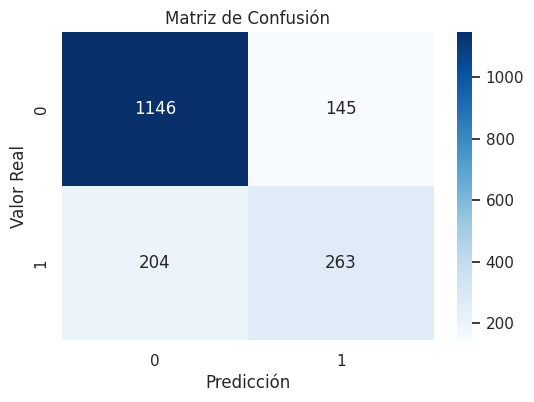

Recall: 0.563169164882227
F1-Score: 0.6011428571428571


In [ ]:
from sklearn.metrics import confusion_matrix, recall_score, f1_score
import seaborn as sns
import matplotlib.pyplot as plt

# Predicciones
y_pred = modelo.predict(X_test_encoded)

# Matriz de confusión
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title("Matriz de Confusión")
plt.xlabel("Predicción")
plt.ylabel("Valor Real")
plt.show()

# Recall
recall = recall_score(y_test, y_pred)

# F1 Score
f1 = f1_score(y_test, y_pred)

print("Recall:", recall)
print("F1-Score:", f1)

Matriz de Confusión, Recall y F1-Score

Se evaluó el rendimiento del modelo mediante una matriz de confusión, que permite visualizar los aciertos y errores de clasificación. Además, se calcularon las métricas Recall y F1-Score para medir la capacidad del modelo para detectar clientes que abandonan el servicio y evaluar el equilibrio general de su desempeño.